In [1]:
import zipfile

zip_path = "/content/archive.zip"
extract_path = "data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Fayllar çıxarıldı!")

Fayllar çıxarıldı!


In [5]:
with zipfile.ZipFile("/content/archive.zip", 'r') as zip_ref:
    print(zip_ref.namelist())

['traffic.csv']


In [8]:
import pandas as pd
df = pd.read_csv("/content/data/traffic.csv")
print(df.head())
print(df.info())

              DateTime  Junction  Vehicles           ID
0  2015-11-01 00:00:00         1        15  20151101001
1  2015-11-01 01:00:00         1        13  20151101011
2  2015-11-01 02:00:00         1        10  20151101021
3  2015-11-01 03:00:00         1         7  20151101031
4  2015-11-01 04:00:00         1         9  20151101041
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None


In [9]:
print(df.isnull().sum())

df = df.fillna(method='ffill')
df = df.drop_duplicates()
if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['hour'] = df['datetime'].dt.hour
    df['day'] = df['datetime'].dt.day
    df['month'] = df['datetime'].dt.month

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64


/tmp/ipykernel_15292/1344133960.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

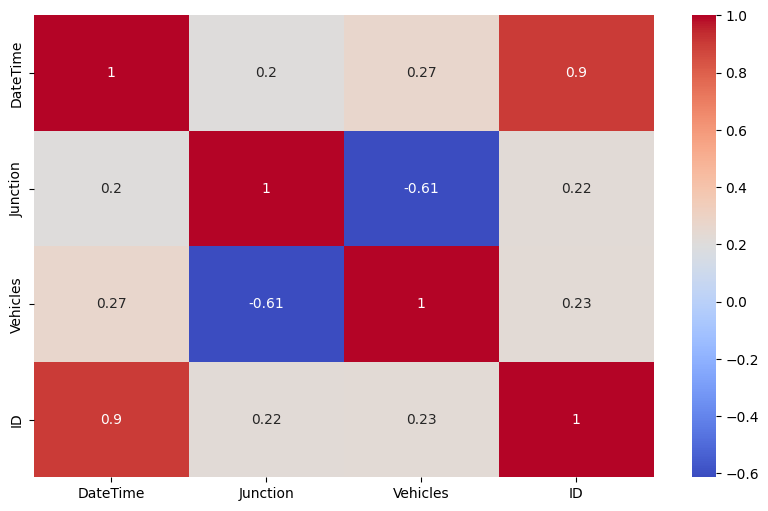

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

if 'traffic_volume' in df.columns:
    plt.figure(figsize=(10,5))
    plt.plot(df['traffic_volume'])
    plt.title("Traffic Volume")
    plt.show()

In [13]:
print(df.columns)

Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='object')


In [14]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

df['hour'] = df['DateTime'].dt.hour
df['day'] = df['DateTime'].dt.day
df['month'] = df['DateTime'].dt.month

In [15]:
target = 'Vehicles'

X = df.drop(columns=[target, 'DateTime'])
y = df[target]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 94.54699285677285
R2: 0.7680094510317113


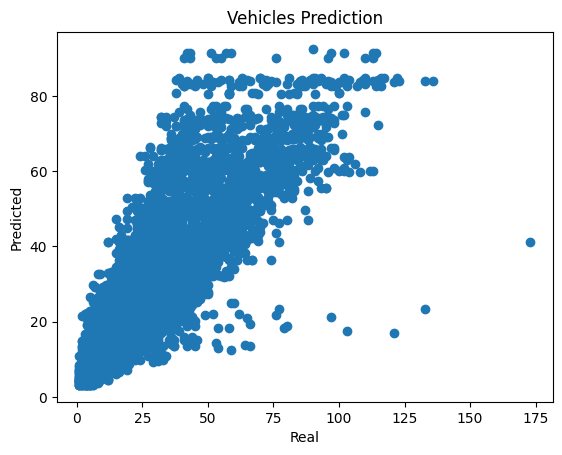

In [20]:
plt.scatter(y_test, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicted")
plt.title("Vehicles Prediction")
plt.show()

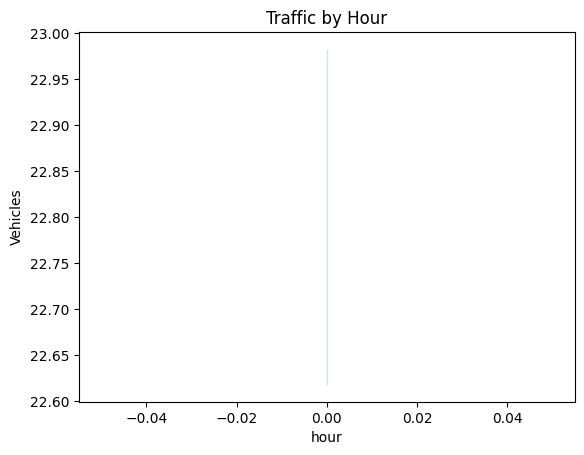

In [21]:
import seaborn as sns

sns.lineplot(x=df['hour'], y=df['Vehicles'])
plt.title("Traffic by Hour")
plt.show()

In [24]:
train_columns = X_train.columns

In [25]:
new_data = pd.DataFrame({
    'Junction': [1],
    'hour': [18],
    'day': [15],
    'month': [4]
})

In [26]:
new_data = new_data.reindex(columns=train_columns, fill_value=0)

In [27]:
prediction = model.predict(new_data)
print(prediction)

[18.43213174]


In [29]:
!pip install python-pptx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 14.8 MB/s eta 0:00:00


In [33]:


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

from pptx import Presentation
from pptx.util import Inches



df = pd.read_csv("/content/data/traffic.csv")

df['DateTime'] = pd.to_datetime(df['DateTime'])
df['hour'] = df['DateTime'].dt.hour
df['day'] = df['DateTime'].dt.day
df['month'] = df['DateTime'].dt.month

df = df.drop(columns=['ID'])



X = df[['Junction','hour','day','month']]
y = df['Vehicles']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)



r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)
print("Accuracy (%):", round(r2 * 100, 2))



df.groupby('hour')['Vehicles'].mean().plot()
plt.title("Traffic by Hour")
plt.savefig("hour.png")
plt.close()


df.groupby('Junction')['Vehicles'].mean().plot(kind='bar')
plt.title("Traffic by Junction")
plt.savefig("junction.png")
plt.close()


plt.scatter(y_test, y_pred)
plt.title("Real vs Predicted")
plt.savefig("pred.png")
plt.close()



prs = Presentation()


slide = prs.slides.add_slide(prs.slide_layouts[0])
slide.shapes.title.text = "Traffic Prediction using ML"
slide.placeholders[1].text = "Ad Soyad:Ruslan Asgarov\nQrup:2444i\nTransportation Project"


slide = prs.slides.add_slide(prs.slide_layouts[1])
slide.shapes.title.text = "Project Explanation"
slide.placeholders[1].text = """
Dataset: Traffic Sensor Data
Features: Junction, hour, day, month
Target: Vehicles
Model: Random Forest Regression
Process: Cleaning → Training → Prediction
"""


slide = prs.slides.add_slide(prs.slide_layouts[5])
slide.shapes.title.text = "Visual Results"

slide.shapes.add_picture("hour.png", Inches(0.5), Inches(1.5), width=Inches(3))
slide.shapes.add_picture("junction.png", Inches(3.5), Inches(1.5), width=Inches(3))
slide.shapes.add_picture("pred.png", Inches(2), Inches(4))


slide = prs.slides.add_slide(prs.slide_layouts[1])
slide.shapes.title.text = "Model Accuracy"

slide.placeholders[1].text = f"""
R2 Score: {round(r2, 4)}
Prediction Accuracy: {round(r2 * 100, 2)}%
"""


prs.save("traffic_ml_presentation.pptx")

print("DONE  PPT READY")

R2 Score: 0.4126693643270062
Accuracy (%): 41.27
DONE  PPT READY


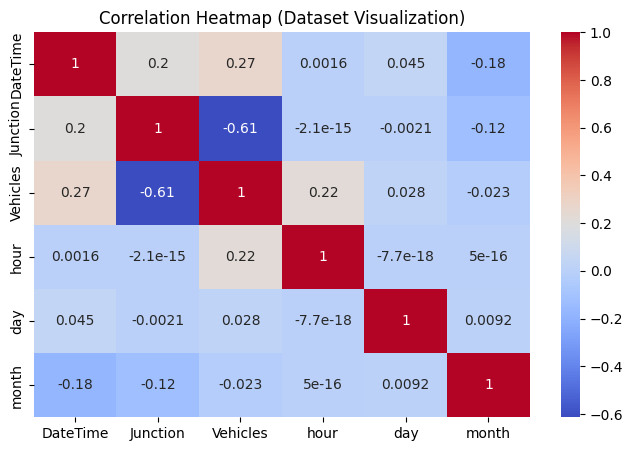

In [35]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap (Dataset Visualization)")
plt.savefig("heatmap.png", dpi=300, bbox_inches='tight')
plt.show()